In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/cascades/3.1/LRG/alltiles_LRGzinfo.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS'])
idx = np.where(tmp['TARGETS']=='QSO+LRG')[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

674227
37119


In [4]:
deep = zbest.copy()

# Select deep coadds
mask = deep['subset']=='deep'
print(np.sum(mask))
# # Select QSO+LRG tiles
# mask &= deep['TARGETS']=='QSO+LRG'
# print(np.sum(mask))
deep = deep[mask]

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# Ting-Wen's quality cuts
mask = deep['DELTACHI2']>20
mask &= deep['Z']<1.4
mask &= deep['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep))
print(len(np.unique(deep['TARGETID'])))

deep_columns_old = ['Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'SUBTYPE', 'DELTACHI2', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR', 'EFFTIME_DARK', 'EFFTIME_BRIGHT', 'EFFTIME_BACK']
deep_columns_new = ['Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'SUBTYPE_deep', 'DELTACHI2_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep', 'EFFTIME_DARK_deep', 'EFFTIME_BRIGHT_deep', 'EFFTIME_BACK_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

34868
FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 18686 10684 0.636227442969016
Quality cuts 18202 484 0.9740982553783581
18202
18202


__Add Galactic extinction columns from sweep catalogs (it might take a minute or two)__

In [5]:
ls_columns = ['MW_TRANSMISSION_G', 'MW_TRANSMISSION_R', 'MW_TRANSMISSION_Z', 'MW_TRANSMISSION_W1', 'MW_TRANSMISSION_W2']

# Snippets taken from desitarget

from desitarget.targets import encode_targetid

def decode_sweep_name(sweepname):
    sweepname = os.path.basename(sweepname)

    ramin, ramax = float(sweepname[6:9]), float(sweepname[14:17])
    decmin, decmax = float(sweepname[10:13]), float(sweepname[18:21])

    if sweepname[9] == 'm':
        decmin *= -1
    if sweepname[17] == 'm':
        decmax *= -1

    return [ramin, ramax, decmin, decmax]

def is_in_box(objs, radecbox, ra_col='RA', dec_col='DEC'):

    ramin, ramax, decmin, decmax = radecbox

    # ADM check for some common mistakes.
    if decmin < -90. or decmax > 90. or decmax <= decmin or ramax <= ramin:
        msg = "Strange input: [ramin, ramax, decmin, decmax] = {}".format(radecbox)
        log.critical(msg)
        raise ValueError(msg)

    ii = ((objs[ra_col] >= ramin) & (objs[ra_col] < ramax)
          & (objs[dec_col] >= decmin) & (objs[dec_col] < decmax))

    return ii

# Ignore any possible north/south overlap

sweep_fn_list = []
for field in ['north', 'south']:
    sweep_dir = '/global/cfs/cdirs/cosmo/data/legacysurvey/dr9/{}/sweep/9.0'.format(field)
    sweep_fn_list += sorted(glob.glob(os.path.join(sweep_dir, '*.fits')))
sweep_fn_list = np.array(sweep_fn_list)

sweep_radec_list = [decode_sweep_name(sweep_fn) for sweep_fn in sweep_fn_list]
mask = np.array([np.any(is_in_box(deep, sweep_radec, ra_col='TARGET_RA', dec_col='TARGET_DEC')) for sweep_radec in sweep_radec_list])
print(np.sum(mask))
sweep_fn_list = sweep_fn_list[mask]

ls_stack = []
for sweep_fn in sweep_fn_list:
    ls = Table(fitsio.read(sweep_fn, columns=['OBJID', 'BRICKID', 'RELEASE']))
    targetid = encode_targetid(ls['OBJID'], ls['BRICKID'], ls['RELEASE'])
    idx = np.where(np.in1d(targetid, deep['TARGETID']))[0]
    if len(idx)==0:
        continue
    targetid = targetid[idx]
    ls = Table(fitsio.read(sweep_fn, rows=idx, columns=ls_columns))
    ls['TARGETID'] = targetid
    # if '/south/sweep/' in sweep_fn:
    #     ls['field'] = 'south'
    # else:
    #     ls['field'] = 'north'
    # pz_fn = sweep_fn.replace('sweep/9.0/', 'sweep/9.0-photo-z/').replace('.fits', '-pz.fits')
    # pz = Table(fitsio.read(pz_fn, rows=idx))
    # pz.remove_columns(['OBJID', 'BRICKID', 'RELEASE'])
    # ls = hstack([ls, pz])
    ls_stack.append(ls)
ls = vstack(ls_stack)
print(len(deep), len(ls))

deep = join(deep, ls, keys='TARGETID')

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    deep['gmag'] = 22.5 - 2.5*np.log10(deep['FLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rmag'] = 22.5 - 2.5*np.log10(deep['FLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zmag'] = 22.5 - 2.5*np.log10(deep['FLUX_Z']/deep['MW_TRANSMISSION_Z'])
    deep['w1mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W1']/deep['MW_TRANSMISSION_W1'])
    deep['w2mag'] = 22.5 - 2.5*np.log10(deep['FLUX_W2']/deep['MW_TRANSMISSION_W2'])
    deep['gfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_G']/deep['MW_TRANSMISSION_G'])
    deep['rfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_R']/deep['MW_TRANSMISSION_R'])
    deep['zfibermag'] = 22.5 - 2.5*np.log10(deep['FIBERFLUX_Z']/deep['MW_TRANSMISSION_Z'])

31
18202 18202


In [6]:
mask = zbest['RZR']=='single_exposures'
zbest = zbest[mask]
print(len(zbest))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
zbest = zbest[mask]
print(len(zbest))

print(len(np.unique(zbest['TARGETID'])))

deep_columns = deep_columns_new+['TARGETID', 'gmag', 'rmag', 'zmag', 'w1mag', 'w2mag', 'gfibermag', 'rfibermag', 'zfibermag']
zbest = join(zbest, deep[deep_columns], keys='TARGETID')

429668
232373
18202


In [7]:
lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)
print(np.sum(lrg_opt))
print(np.sum(lrg_ir))
print(np.sum(lrg_sv))
print()

sv_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(sv_qso))
print(np.sum(sv_qso & lrg_sv))
print(np.sum(sv_qso & lrg_opt))

62025
65420
232373

5223
5223
495


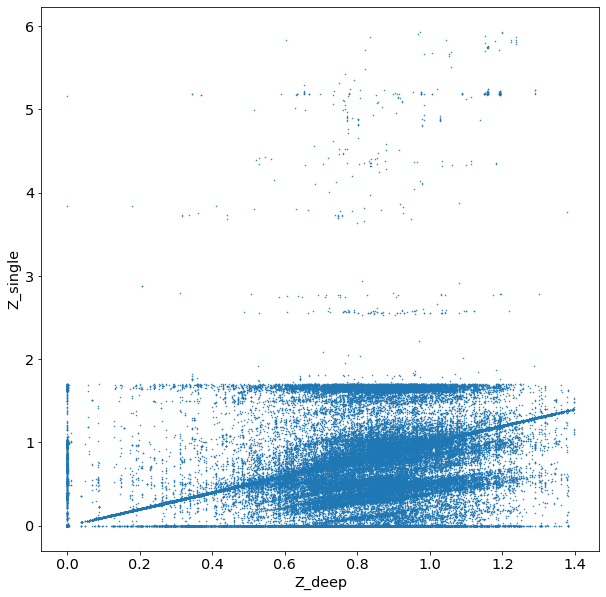

In [8]:
# All SV LRGs from all single exposures
plt.figure(figsize=(10, 10))
plt.plot(zbest['Z_deep'], zbest['Z'], '.', ms=1)
plt.xlabel('Z_deep')
plt.ylabel('Z_single')
plt.show()

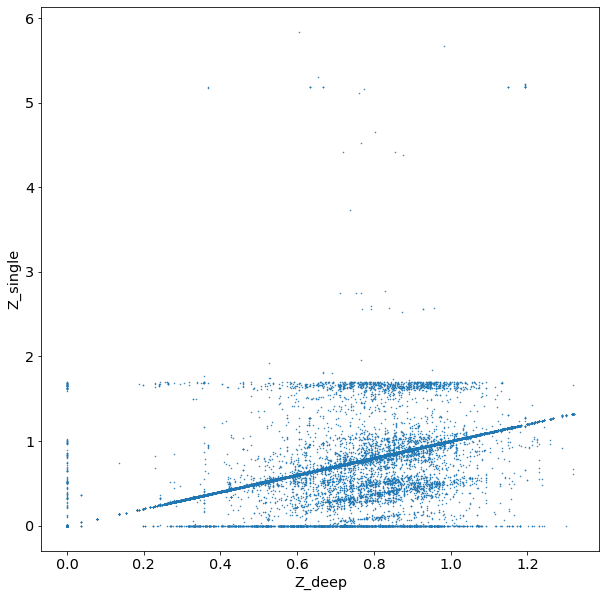

In [9]:
# OPT LRGs
plt.figure(figsize=(10, 10))
plt.plot(zbest['Z_deep'][lrg_opt], zbest['Z'][lrg_opt], '.', ms=1)
plt.xlabel('Z_deep')
plt.ylabel('Z_single')
plt.show()

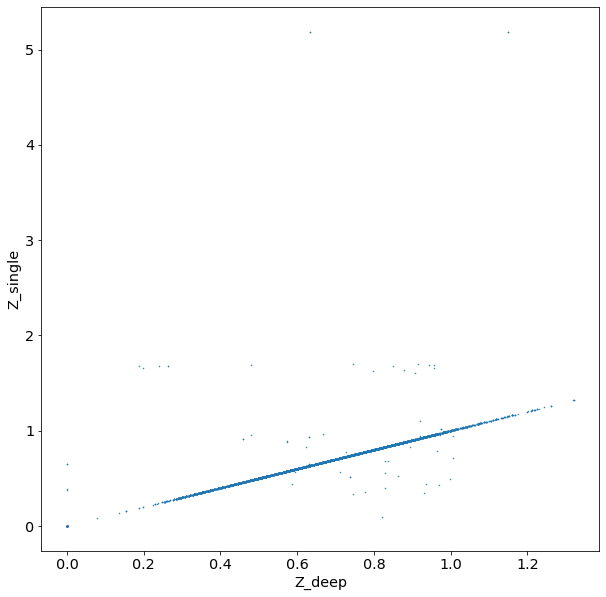

In [10]:
# OPT LRGs with ~1000s effective exposure times
mask = lrg_opt & (zbest['EFFTIME_DARK']>900) & (zbest['EFFTIME_DARK']<1100)

plt.figure(figsize=(10, 10))
plt.plot(zbest['Z_deep'][mask], zbest['Z'][mask], '.', ms=1)
plt.xlabel('Z_deep')
plt.ylabel('Z_single')
plt.show()